# Visualización del entrenamiento y del campo de velocidad — 9mm CFD

Este notebook analiza los resultados de `Exp_24_Jul_2`:

- pérdidas de entrenamiento y pesos adaptativos;
- evolución del nuevo criterio de *early stopping*;
- velocidad real y predicha;
- campos vectoriales 3D;
- errores por componente y por instante;
- divergencia del campo predicho.

Por defecto se carga el run más reciente que contenga `best_velocity.pth`. Para analizar otro run, cambia `velocity_run_name` en la siguiente celda.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

# ============================================================
# Configuración editable
# ============================================================
project_dir = Path("/proj/multipress/users/x_sebja/Exp_32_Jul_cfd")
experiment_name = "normal_CFD"

# None selecciona automáticamente el run más reciente.
# Ejemplo: velocity_run_name = "seed_004_20260724_151855"
velocity_run_name = None

time_index = 7
prediction_batch_size = 20_000
divergence_batch_size = 4_000
vector_stride = 3
use_cuda = True

experiment_dir = project_dir / experiment_name
data_dir = experiment_dir / "data"
data_train_dir = experiment_dir / "data_train"
results_dir = data_train_dir / "results"
scr_dir = project_dir / "scr"

if str(scr_dir) not in sys.path:
    sys.path.insert(0, str(scr_dir))

from NN import MLP

torch.set_default_dtype(torch.float64)
# device = torch.device(
#     "cuda" if use_cuda and torch.cuda.is_available() else "cpu"
# )

device = "cpu"


plt.style.use("seaborn-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

print("Project:", project_dir)
print("Device: ", device)

Project: /proj/multipress/users/x_sebja/Exp_32_Jul_cfd
Device:  cpu


In [2]:
# ============================================================
# Seleccionar run y cargar checkpoints, datos y metadatos
# ============================================================
available_runs = sorted(
    p for p in results_dir.glob("seed_*")
    if (p / "checkpoints" / "best_velocity.pth").exists()
)

if not available_runs:
    raise FileNotFoundError(
        f"No se encontraron runs con best_velocity.pth en:\n{results_dir}"
    )

if velocity_run_name is None:
    run_dir = max(available_runs, key=lambda p: p.stat().st_mtime)
    velocity_run_name = run_dir.name
else:
    run_dir = results_dir / velocity_run_name

best_checkpoint_path = run_dir / "checkpoints" / "best_velocity.pth"
last_checkpoint_path = run_dir / "checkpoints" / "checkpoint_last.pth"
sampling_path = run_dir / "sampling" / "sampling_index.npz"
normalization_path = run_dir / "sampling" / "dic_adim_norm.npz"
validation_csv_path = run_dir / "logs" / "validation_history.csv"
summary_path = run_dir / "logs" / "training_summary.json"
data_path = data_dir / "centerline_velocity_vectors_normal_array3d.npy"

for required_path in [best_checkpoint_path, normalization_path, data_path]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

best_ckpt = torch.load(best_checkpoint_path, map_location="cpu")
last_ckpt = (
    torch.load(last_checkpoint_path, map_location="cpu")
    if last_checkpoint_path.exists() else None
)
normalization_npz = np.load(normalization_path, allow_pickle=True)
normalization = {key: normalization_npz[key] for key in normalization_npz.files}
Data = np.load(data_path, allow_pickle=True)

summary = {}
if summary_path.exists():
    with summary_path.open("r", encoding="utf-8") as file:
        summary = json.load(file)

history_source = last_ckpt if last_ckpt is not None else best_ckpt
extra_state = history_source.get("extra_state", {})
history = history_source.get("history", extra_state.get("history", {}))
validation_history = history_source.get(
    "validation_history",
    extra_state.get("validation_history", []),
)

# El historial del checkpoint conserva el orden correcto incluso para
# runs antiguos cuyo encabezado CSV pudiera estar desalineado.
if validation_history:
    validation_df = pd.DataFrame(validation_history)
elif validation_csv_path.exists():
    validation_df = pd.read_csv(validation_csv_path)
else:
    validation_df = pd.DataFrame()

best_epoch = int(best_ckpt.get("epoch", summary.get("best_epoch", -1)))
stop_epoch = int(
    history_source.get("epoch", summary.get("last_epoch", best_epoch))
)
best_metric = best_ckpt.get(
    "validation_metric",
    summary.get("best_validation_selection_score", np.nan),
)

run_information = pd.DataFrame({
    "valor": {
        "run": velocity_run_name,
        "best epoch": best_epoch,
        "stop epoch": stop_epoch,
        "best selection metric": best_metric,
        "training seed": summary.get("training_seed", "n/d"),
        "split seed": summary.get("split_seed", "n/d"),
        "data shape": str(Data.shape),
        "best checkpoint": str(best_checkpoint_path),
    }
})

display(run_information)
print("Runs disponibles:")
for path in available_runs:
    print("  ", path.name)

,valor
best checkpoint,/proj/multipress/users/x_sebja/Exp_32_Jul_cfd/...
best epoch,100000
best selection metric,0.130362
data shape,"(28, 2497, 7)"
run,seed_005_20260814_142838
split seed,43
stop epoch,100000
training seed,5


Runs disponibles:
   seed_001_20260814_142008
   seed_002_20260814_142120
   seed_003_20260814_142709
   seed_004_20260814_142813
   seed_005_20260814_142838


In [3]:
# ============================================================
# Reconstruir la MLP y cargar el mejor modelo
# ============================================================
def scalar(name):
    return float(np.asarray(normalization[name]).squeeze())

L = scalar("L")
T = scalar("T")
U = scalar("U")
rho = scalar("rho")
mu = scalar("mu")
p0 = scalar("p0")
Re = scalar("Re")

mu_x, mu_y, mu_z = (scalar("mu_x"), scalar("mu_y"), scalar("mu_z"))
mu_t = scalar("mu_t")
sigma_x, sigma_y, sigma_z = (
    scalar("sigma_x"), scalar("sigma_y"), scalar("sigma_z")
)
sigma_t = scalar("sigma_t")

# Debe coincidir con main_data_early_stopping_p12.py
net = MLP(
    input_size=4,
    output_size=3,
    hidden_layers=4,
    hidden_units=64,
    activation_fn=nn.SiLU(),
).to(device)

net.load_state_dict(best_ckpt["model_state_dict"])
net.eval()

n_parameters = sum(parameter.numel() for parameter in net.parameters())
print(net)
print(f"Parámetros entrenables: {n_parameters:,}")
print(f"L={L:.6g}, T={T:.6g}, U={U:.6g}, Re={Re:.3f}")

MLP(
  (activation_fn): SiLU()
  (in_layer): Linear(in_features=4, out_features=64, bias=True)
  (hidden): ModuleList(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (out_layer): Linear(in_features=64, out_features=3, bias=True)
)
Parámetros entrenables: 17,155
L=0.09, T=0.09, U=1, Re=20850.932


## Entrenamiento y early stopping

La línea vertical verde marca el mejor checkpoint y la roja el final del entrenamiento. El score restringido puede tomar `inf` cuando no se satisface la restricción de divergencia.

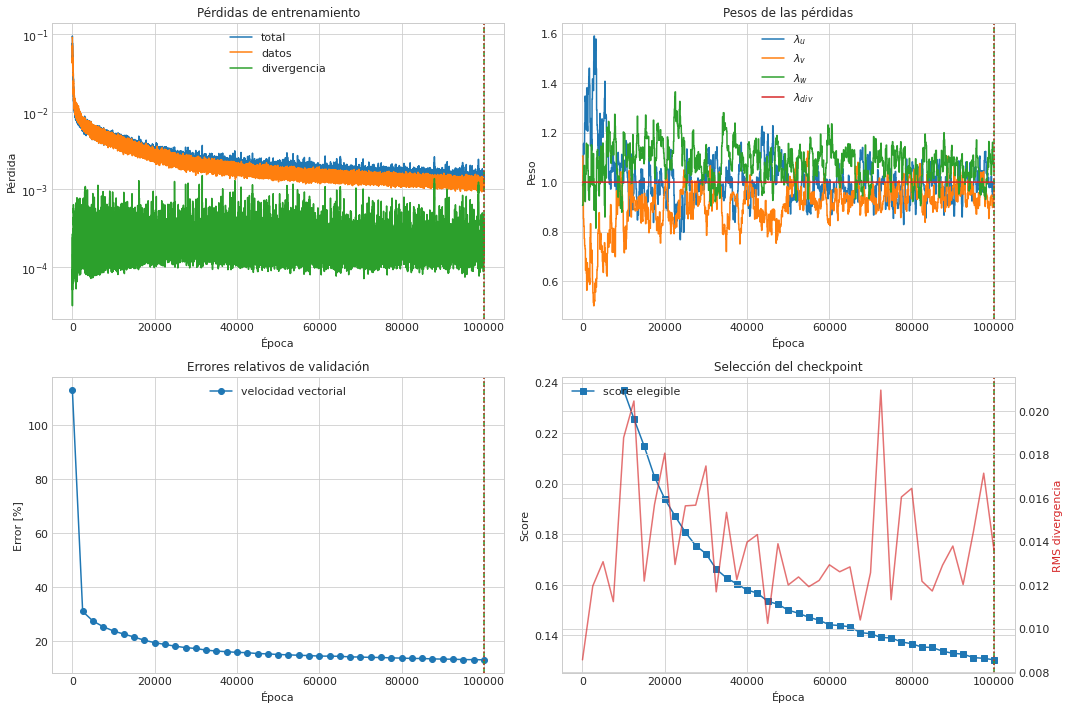

In [4]:
def history_array(key):
    return np.asarray(history.get(key, []), dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pérdidas
ax = axes[0, 0]
for key, label in [
    ("total_loss", "total"),
    ("loss_data", "datos"),
    ("loss_div", "divergencia"),
]:
    values = history_array(key)
    if values.size:
        ax.semilogy(np.arange(values.size), np.maximum(values, 1e-18), label=label)
ax.set(title="Pérdidas de entrenamiento", xlabel="Época", ylabel="Pérdida")
ax.legend()

# 2. Pesos
ax = axes[0, 1]
for key, label in [
    ("lambda_data_u", r"$\lambda_u$"),
    ("lambda_data_v", r"$\lambda_v$"),
    ("lambda_data_w", r"$\lambda_w$"),
    ("lambda_div", r"$\lambda_{div}$"),
]:
    values = history_array(key)
    if values.size:
        ax.plot(np.arange(values.size), values, label=label)
ax.set(title="Pesos de las pérdidas", xlabel="Época", ylabel="Peso")
ax.legend()

# 3. Calidad de validación
ax = axes[1, 0]
if not validation_df.empty:
    epoch_val = validation_df["epoch"].to_numpy()
    for key, label in [
        ("relative_l2_velocity_vector", "velocidad vectorial"),
        ("relative_l2_increment_space", "incremento espacial"),
        ("relative_l2_increment_time", "incremento temporal"),
    ]:
        if key in validation_df:
            ax.plot(epoch_val, 100 * validation_df[key], marker="o", label=label)
ax.set(title="Errores relativos de validación", xlabel="Época", ylabel="Error [%]")
ax.legend()

# 4. Score y divergencia
ax = axes[1, 1]
if not validation_df.empty:
    epoch_val = validation_df["epoch"].to_numpy()
    if "selection_score_unconstrained" in validation_df:
        ax.plot(
            epoch_val,
            validation_df["selection_score_unconstrained"],
            marker="o", label="score sin restricción",
        )
    if "selection_score" in validation_df:
        score = pd.to_numeric(validation_df["selection_score"], errors="coerce")
        finite = np.isfinite(score)
        ax.plot(epoch_val[finite], score[finite], marker="s", label="score elegible")
    ax_div = ax.twinx()
    if "rms_divergence" in validation_df:
        ax_div.plot(
            epoch_val, validation_df["rms_divergence"],
            color="tab:red", alpha=0.65, label="RMS divergencia",
        )
        ax_div.set_ylabel("RMS divergencia", color="tab:red")
ax.set(title="Selección del checkpoint", xlabel="Época", ylabel="Score")
ax.legend(loc="upper left")

for ax in axes.ravel():
    if best_epoch >= 0:
        ax.axvline(best_epoch, color="tab:green", linestyle="--", label="best")
    if stop_epoch >= 0:
        ax.axvline(stop_epoch, color="tab:red", linestyle=":", label="stop")

fig.tight_layout()
plt.show()

In [5]:
# Tabla de validación alrededor del mejor checkpoint
if validation_df.empty:
    print("No hay historial de validación disponible.")
else:
    columns = [
        "epoch",
        "relative_l2_velocity_vector",
        "relative_l2_increment_space",
        "relative_l2_increment_time",
        "rms_divergence",
        "normalized_divergence",
        "divergence_constraint_satisfied",
        "selection_score_unconstrained",
        "selection_score",
        "improved",
    ]
    columns = [column for column in columns if column in validation_df]
    nearest_rows = validation_df.iloc[
        np.argsort(np.abs(validation_df["epoch"] - best_epoch))[:7]
    ].sort_values("epoch")
    display(nearest_rows[columns])

,epoch,relative_l2_velocity_vector,rms_divergence,divergence_constraint_satisfied,selection_score,improved
34,85000,0.135264,0.011724,True,0.135264,False
35,87500,0.133781,0.012911,True,0.133781,True
36,90000,0.132951,0.013791,True,0.132951,True
37,92500,0.132601,0.012022,True,0.132601,True
38,95000,0.131250,0.014450,True,0.131250,True
39,97500,0.130953,0.017138,True,0.130953,True
40,100000,0.130362,0.013594,True,0.130362,True


## Predicción del campo completo

Las predicciones se expresan en unidades físicas multiplicando la salida adimensional de la red por `U`.

In [6]:
def normalize_coordinates(data):
    flat = data.reshape(-1, data.shape[-1])
    x = (flat[:, 0:1] / L - mu_x) / sigma_x
    y = (flat[:, 1:2] / L - mu_y) / sigma_y
    z = (flat[:, 2:3] / L - mu_z) / sigma_z
    t = (flat[:, 3:4] / T - mu_t) / sigma_t
    return np.concatenate([x, y, z, t], axis=1)


def predict_velocity(model, normalized_coordinates, batch_size=20_000):
    chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(normalized_coordinates), batch_size):
            stop = min(start + batch_size, len(normalized_coordinates))
            batch = torch.as_tensor(
                normalized_coordinates[start:stop],
                dtype=torch.float64,
                device=device,
            )
            prediction = model(
                batch[:, 0:1], batch[:, 1:2],
                batch[:, 2:3], batch[:, 3:4],
            )
            chunks.append(prediction.cpu().numpy())
    return np.concatenate(chunks, axis=0)


X_normalized = normalize_coordinates(Data)
velocity_pred_dimensionless = predict_velocity(
    net, X_normalized, prediction_batch_size
)
velocity_pred = (
    velocity_pred_dimensionless.reshape(Data.shape[0], Data.shape[1], 3) * U
)
velocity_true = Data[:, :, 4:7].astype(float)
coordinates = Data[:, :, 0:3].astype(float)
times = Data[:, 0, 3].astype(float)

speed_true = np.linalg.norm(velocity_true, axis=2)
speed_pred = np.linalg.norm(velocity_pred, axis=2)
velocity_error = velocity_pred - velocity_true
error_magnitude = np.linalg.norm(velocity_error, axis=2)

print("velocity_true:", velocity_true.shape)
print("velocity_pred:", velocity_pred.shape)
print("time range:    ", (times.min(), times.max()))

velocity_true: (28, 2497, 3)
velocity_pred: (28, 2497, 3)
time range:     (0.0, 0.7992)


In [7]:
# Resumen cuantitativo
component_names = ["u", "v", "w"]
rows = []
for component, name in enumerate(component_names):
    reference = velocity_true[:, :, component]
    prediction = velocity_pred[:, :, component]
    error = prediction - reference
    rows.append({
        "variable": name,
        "RMSE": np.sqrt(np.mean(error**2)),
        "MAE": np.mean(np.abs(error)),
        "relative_L2": np.linalg.norm(error) / max(np.linalg.norm(reference), 1e-12),
        "correlation": np.corrcoef(reference.ravel(), prediction.ravel())[0, 1],
    })

speed_error = speed_pred - speed_true
rows.append({
    "variable": "|V|",
    "RMSE": np.sqrt(np.mean(speed_error**2)),
    "MAE": np.mean(np.abs(speed_error)),
    "relative_L2": np.linalg.norm(speed_error) / max(np.linalg.norm(speed_true), 1e-12),
    "correlation": np.corrcoef(speed_true.ravel(), speed_pred.ravel())[0, 1],
})

metrics_summary = pd.DataFrame(rows).set_index("variable")
display(metrics_summary.style.format("{:.6g}"))

,RMSE,MAE,relative_L2,correlation
variable,,,,
u,0.0192275,0.0123721,0.304312,0.951923
v,0.0206062,0.0134984,0.0833307,0.996514
w,0.0201719,0.0128822,0.225449,0.974216
|V|,0.0208448,0.0136553,0.0770731,0.99521


## Campo escalar de velocidad

Se muestran la velocidad real, la predicha y los errores sobre la geometría 3D para el instante elegido.

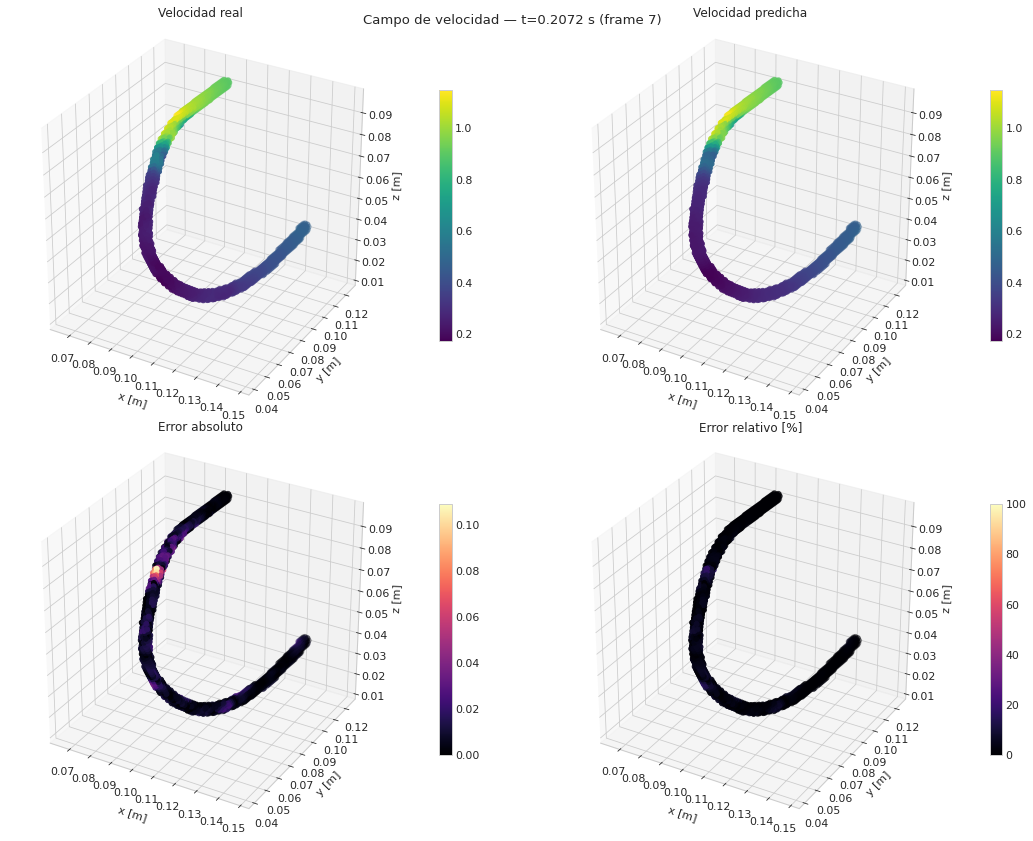

In [8]:
def set_equal_3d_axes(ax, xyz):
    center = xyz.mean(axis=0)
    radius = 0.52 * max(np.ptp(xyz, axis=0).max(), 1e-12)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def plot_velocity_fields(index):
    index = int(np.clip(index, 0, Data.shape[0] - 1))
    xyz = coordinates[index]
    real = speed_true[index]
    predicted = speed_pred[index]
    absolute_error = np.abs(predicted - real)
    relative_error = absolute_error / np.maximum(real, 1e-3)

    common_min = min(real.min(), predicted.min())
    common_max = max(real.max(), predicted.max())

    fig = plt.figure(figsize=(16, 12))
    panels = [
        (real, "Velocidad real", "viridis", common_min, common_max),
        (predicted, "Velocidad predicha", "viridis", common_min, common_max),
        (absolute_error, "Error absoluto", "magma", 0, None),
        (100 * relative_error, "Error relativo [%]", "magma", 0, 100),
    ]

    for panel_index, (values, title, cmap, vmin, vmax) in enumerate(panels, 1):
        ax = fig.add_subplot(2, 2, panel_index, projection="3d")
        scatter = ax.scatter(
            xyz[:, 0], xyz[:, 1], xyz[:, 2],
            c=values, cmap=cmap, s=24, vmin=vmin, vmax=vmax,
        )
        fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.08)
        ax.set(title=title, xlabel="x [m]", ylabel="y [m]", zlabel="z [m]")
        set_equal_3d_axes(ax, xyz)

    fig.suptitle(f"Campo de velocidad — t={times[index]:.6g} s (frame {index})", y=0.95)
    fig.tight_layout()
    plt.show()


plot_velocity_fields(time_index)

## Campos vectoriales

Las flechas están normalizadas para comparar principalmente su dirección; el color representa el módulo de la velocidad.

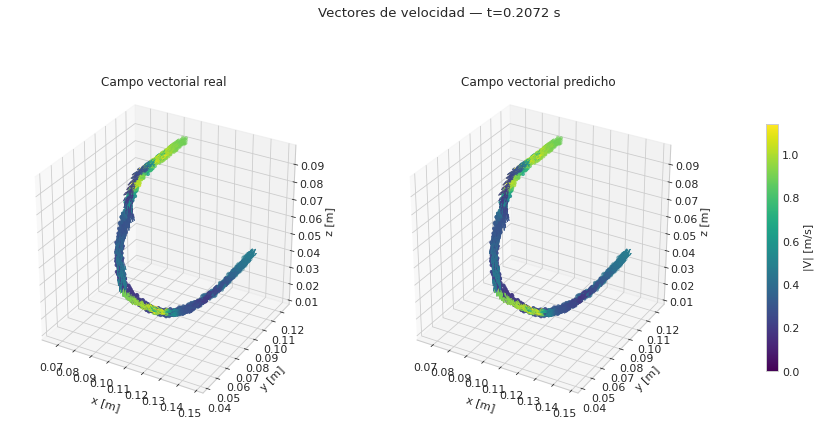

In [9]:
def plot_vector_fields(index, stride=3):
    index = int(np.clip(index, 0, Data.shape[0] - 1))
    selection = np.arange(0, Data.shape[1], max(int(stride), 1))
    xyz = coordinates[index, selection]
    real = velocity_true[index, selection]
    predicted = velocity_pred[index, selection]
    real_speed = np.linalg.norm(real, axis=1)
    predicted_speed = np.linalg.norm(predicted, axis=1)

    vmax = max(real_speed.max(), predicted_speed.max(), 1e-12)
    color_norm = Normalize(0, vmax)
    cmap = plt.get_cmap("viridis")

    fig = plt.figure(figsize=(16, 7))
    for panel, (vectors, speeds, title) in enumerate([
        (real, real_speed, "Campo vectorial real"),
        (predicted, predicted_speed, "Campo vectorial predicho"),
    ], 1):
        ax = fig.add_subplot(1, 2, panel, projection="3d")
        colors = cmap(color_norm(speeds))
        ax.quiver(
            xyz[:, 0], xyz[:, 1], xyz[:, 2],
            vectors[:, 0], vectors[:, 1], vectors[:, 2],
            length=0.006, normalize=True, colors=colors,
            linewidth=0.8, arrow_length_ratio=0.35,
        )
        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=speeds, cmap=cmap, norm=color_norm, s=8)
        ax.set(title=title, xlabel="x [m]", ylabel="y [m]", zlabel="z [m]")
        set_equal_3d_axes(ax, xyz)

    scalar_mappable = plt.cm.ScalarMappable(norm=color_norm, cmap=cmap)
    scalar_mappable.set_array([])
    fig.colorbar(scalar_mappable, ax=fig.axes, shrink=0.65, pad=0.08, label="|V| [m/s]")
    fig.suptitle(f"Vectores de velocidad — t={times[index]:.6g} s")
    plt.show()


plot_vector_fields(time_index, vector_stride)

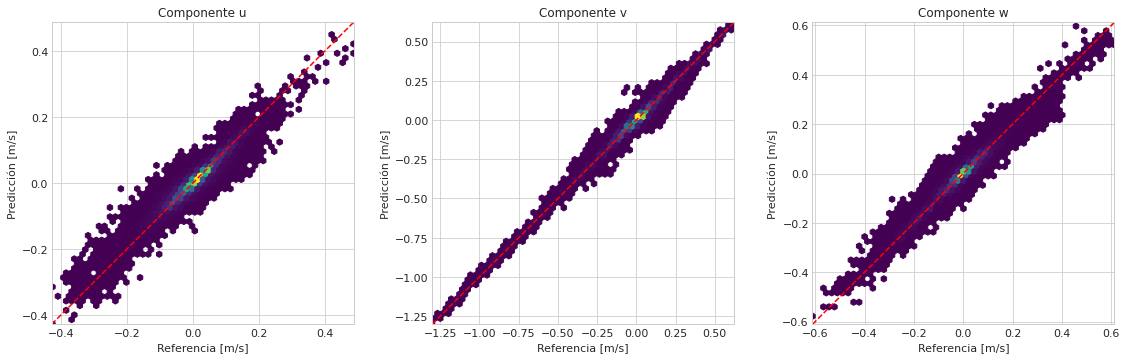

In [10]:
# Comparación predicción-referencia por componente
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for component, (ax, name) in enumerate(zip(axes, component_names)):
    reference = velocity_true[:, :, component].ravel()
    prediction = velocity_pred[:, :, component].ravel()
    lower = min(reference.min(), prediction.min())
    upper = max(reference.max(), prediction.max())
    ax.hexbin(reference, prediction, gridsize=55, mincnt=1, cmap="viridis")
    ax.plot([lower, upper], [lower, upper], "r--", linewidth=1.5)
    ax.set(
        title=f"Componente {name}",
        xlabel="Referencia [m/s]",
        ylabel="Predicción [m/s]",
        xlim=(lower, upper),
        ylim=(lower, upper),
    )
    ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

## Evolución temporal del error

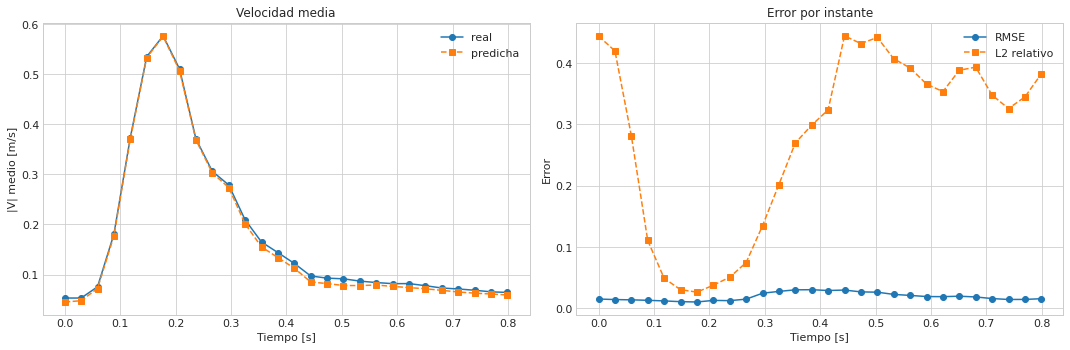

,time,rmse_velocity,relative_l2_velocity,mean_speed_true,mean_speed_pred
0,0.0000,0.014999,0.444285,0.052971,0.045081
1,0.0296,0.014101,0.420096,0.052992,0.047609
2,0.0592,0.013638,0.281774,0.075420,0.071972
3,0.0888,0.012904,0.110595,0.180616,0.177387
4,0.1184,0.011889,0.048921,0.373782,0.370974
5,0.1480,0.010682,0.030217,0.535436,0.533499
6,0.1776,0.010136,0.026240,0.577054,0.575968
7,0.2072,0.012733,0.037510,0.511048,0.507674
8,0.2368,0.012337,0.050580,0.371195,0.369218
9,0.2664,0.014767,0.074467,0.306299,0.303283


In [11]:
rmse_per_frame = np.sqrt(np.mean(velocity_error**2, axis=(1, 2)))
relative_l2_per_frame = np.array([
    np.linalg.norm(velocity_error[index])
    / max(np.linalg.norm(velocity_true[index]), 1e-12)
    for index in range(Data.shape[0])
])
mean_speed_true = speed_true.mean(axis=1)
mean_speed_pred = speed_pred.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(times, mean_speed_true, "o-", label="real")
axes[0].plot(times, mean_speed_pred, "s--", label="predicha")
axes[0].set(title="Velocidad media", xlabel="Tiempo [s]", ylabel="|V| medio [m/s]")
axes[0].legend()

axes[1].plot(times, rmse_per_frame, "o-", label="RMSE")
axes[1].plot(times, relative_l2_per_frame, "s--", label="L2 relativo")
axes[1].set(title="Error por instante", xlabel="Tiempo [s]", ylabel="Error")
axes[1].legend()
fig.tight_layout()
plt.show()

display(pd.DataFrame({
    "time": times,
    "rmse_velocity": rmse_per_frame,
    "relative_l2_velocity": relative_l2_per_frame,
    "mean_speed_true": mean_speed_true,
    "mean_speed_pred": mean_speed_pred,
}))

## Diagnóstico de divergencia

La divergencia se calcula con autograd y con los mismos factores de normalización usados durante el entrenamiento. Se expresa para el campo de velocidad adimensional respecto a las coordenadas espaciales adimensionales.

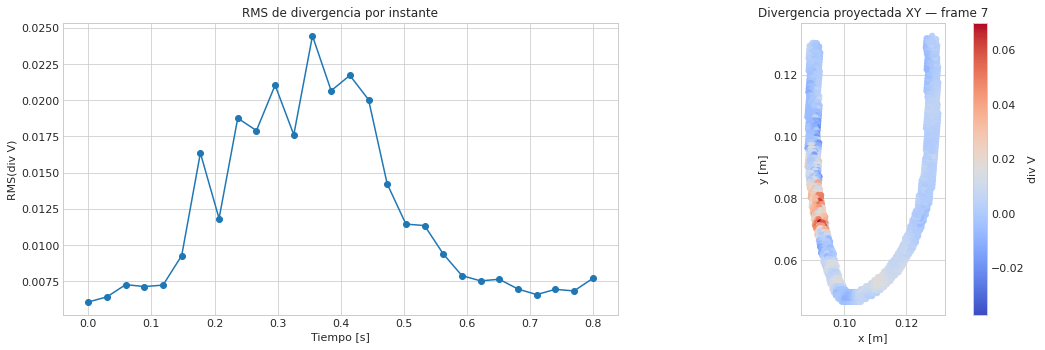

RMS divergencia global: 1.338999e-02
Máximo |divergencia|:   1.242702e-01


In [12]:
def predict_divergence(model, normalized_coordinates, batch_size=4_000):
    chunks = []
    model.eval()
    for start in range(0, len(normalized_coordinates), batch_size):
        stop = min(start + batch_size, len(normalized_coordinates))
        batch = torch.as_tensor(
            normalized_coordinates[start:stop],
            dtype=torch.float64,
            device=device,
        ).requires_grad_(True)
        x, y, z, t = (batch[:, i:i+1] for i in range(4))
        prediction = model(x, y, z, t)
        u_x = torch.autograd.grad(
            prediction[:, 0:1], x,
            grad_outputs=torch.ones_like(prediction[:, 0:1]),
            retain_graph=True,
        )[0] / sigma_x
        v_y = torch.autograd.grad(
            prediction[:, 1:2], y,
            grad_outputs=torch.ones_like(prediction[:, 1:2]),
            retain_graph=True,
        )[0] / sigma_y
        w_z = torch.autograd.grad(
            prediction[:, 2:3], z,
            grad_outputs=torch.ones_like(prediction[:, 2:3]),
        )[0] / sigma_z
        chunks.append((u_x + v_y + w_z).detach().cpu().numpy())
    return np.concatenate(chunks).reshape(Data.shape[0], Data.shape[1])


divergence_pred = predict_divergence(
    net, X_normalized, divergence_batch_size
)
rms_divergence_per_frame = np.sqrt(np.mean(divergence_pred**2, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(times, rms_divergence_per_frame, "o-")
axes[0].set(
    title="RMS de divergencia por instante",
    xlabel="Tiempo [s]", ylabel="RMS(div V)",
)

index = int(np.clip(time_index, 0, Data.shape[0] - 1))
xyz = coordinates[index]
scatter = axes[1].scatter(
    xyz[:, 0], xyz[:, 1],
    c=divergence_pred[index], cmap="coolwarm", s=28,
)
fig.colorbar(scatter, ax=axes[1], label="div V")
axes[1].set(
    title=f"Divergencia proyectada XY — frame {index}",
    xlabel="x [m]", ylabel="y [m]",
)
axes[1].set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

print(f"RMS divergencia global: {np.sqrt(np.mean(divergence_pred**2)):.6e}")
print(f"Máximo |divergencia|:   {np.max(np.abs(divergence_pred)):.6e}")

## Exploración interactiva opcional

Ejecuta la siguiente celda si `ipywidgets` está habilitado en Jupyter.

In [13]:
try:
    from ipywidgets import interact, IntSlider

    interact(
        plot_velocity_fields,
        index=IntSlider(
            min=0,
            max=Data.shape[0] - 1,
            step=1,
            value=int(np.clip(time_index, 0, Data.shape[0] - 1)),
            description="Frame",
            continuous_update=False,
        ),
    )
except ImportError:
    print("ipywidgets no está instalado; usa plot_velocity_fields(indice).")

interactive(children=(IntSlider(value=7, continuous_update=False, description='Frame', max=27), Output()), _do…

# Velocity Visualization Data


In [14]:
velocity_true.shape

(28, 2707, 3)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from ipywidgets import interact
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


seg_path = data_dir / "data_dom_normal.npy"
Data_seg = np.load(seg_path, allow_pickle=True) if seg_path.exists() else None
Data_centerline = coordinates[0].copy()


def interactive_velocity_field_3d(
    coordinates,
    velocity_field,
    times,
    Data_seg=None,
    Data_centerline=None,
    title_prefix="Velocidad",
    percentile_min=1,
    percentile_max=99,
    default_frame=0,
    default_azim=-90,
    default_elev=-90,
    point_size_seg=2,
    vector_stride=1,
    vector_length=0.006,
    vector_linewidth=1.4,
    vector_alpha=1.0,
    tip_length_ratio=0.45,
    tip_linewidth_scale=1.0,
    tip_head_ratio=0.65,
    segmentation_alpha=0.22,
    cmap="viridis",
    show_segmentation=False,
    show_centerline=False,
):
    """Visualizacion 3D interactiva del campo vectorial de velocidad."""

    coordinates = np.asarray(coordinates, dtype=np.float64)
    velocity_field = np.asarray(velocity_field, dtype=np.float64)
    times = np.asarray(times, dtype=np.float64).reshape(-1)

    if coordinates.ndim != 3 or coordinates.shape[2] != 3:
        raise ValueError("coordinates debe tener shape (Nt, Np, 3).")

    if velocity_field.ndim != 3 or velocity_field.shape[2] != 3:
        raise ValueError("velocity_field debe tener shape (Nt, Np, 3).")

    if coordinates.shape[:2] != velocity_field.shape[:2]:
        raise ValueError("coordinates y velocity_field deben tener mismo Nt y Np.")

    Nt, Np, _ = coordinates.shape

    if times.shape[0] != Nt:
        raise ValueError("times debe tener longitud Nt.")

    if Data_centerline is None:
        Data_centerline = coordinates[0]
    Data_centerline = np.asarray(Data_centerline, dtype=np.float64)

    if Data_centerline.ndim != 2 or Data_centerline.shape[1] < 3:
        raise ValueError("Data_centerline debe tener shape (Nc, >=3).")

    speed_all = np.linalg.norm(velocity_field, axis=2)
    vmin = np.nanpercentile(speed_all, percentile_min)
    vmax = np.nanpercentile(speed_all, percentile_max)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = np.nanmin(speed_all)
        vmax = np.nanmax(speed_all)

    color_norm = Normalize(vmin=vmin, vmax=vmax)
    color_map = plt.get_cmap(cmap)

    def _get_seg_frame(frame):
        if Data_seg is None:
            return None

        seg = np.asarray(Data_seg, dtype=np.float64)
        if seg.ndim == 3:
            frame = min(max(frame, 0), seg.shape[0] - 1)
            return seg[frame, :, :3]
        if seg.ndim == 2:
            return seg[:, :3]
        return None

    @interact(
        frame=widgets.IntSlider(
            value=int(np.clip(default_frame, 0, Nt - 1)),
            min=0,
            max=Nt - 1,
            step=10,
            description="time step",
            continuous_update=False,
        ),
        azim=widgets.IntSlider(
            value=default_azim,
            min=-180,
            max=180,
            step=1,
            description="azimuth",
            continuous_update=False,
        ),
        elev=widgets.IntSlider(
            value=default_elev,
            min=-90,
            max=90,
            step=1,
            description="elevation",
            continuous_update=False,
        ),
    )
    def _plot(frame, azim, elev):
        xyz = coordinates[frame]
        vel = velocity_field[frame]
        speed = np.linalg.norm(vel, axis=1)
        seg_xyz = _get_seg_frame(frame)

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection="3d")

        if show_segmentation and seg_xyz is not None:
            ax.scatter(
                seg_xyz[:, 0],
                seg_xyz[:, 1],
                seg_xyz[:, 2],
                c="lightgray",
                s=point_size_seg,
                alpha=segmentation_alpha,
                depthshade=False,
            )

        step = max(int(vector_stride), 1)
        idx = np.arange(0, Np, step)
        xyz_sub = xyz[idx]
        vel_sub = vel[idx]
        speed_sub = speed[idx]

        # Normalizar direcciones manualmente para mantener color uniforme en toda la flecha.
        norm_sub = np.linalg.norm(vel_sub, axis=1, keepdims=True)
        dir_sub = vel_sub / np.maximum(norm_sub, 1e-12)

        colors = color_map(color_norm(speed_sub))
        colors[:, 3] = vector_alpha

        tip_length_ratio_local = float(np.clip(tip_length_ratio, 0.05, 0.95))
        tip_head_ratio_local = float(np.clip(tip_head_ratio, 0.20, 0.95))
        shaft_length = vector_length * (1.0 - tip_length_ratio_local)
        tip_length = vector_length * tip_length_ratio_local

        # Cuerpo (casi sin punta)
        ax.quiver(
            xyz_sub[:, 0],
            xyz_sub[:, 1],
            xyz_sub[:, 2],
            dir_sub[:, 0],
            dir_sub[:, 1],
            dir_sub[:, 2],
            length=shaft_length,
            normalize=False,
            colors=colors,
            linewidth=vector_linewidth,
            arrow_length_ratio=0.01,
        )

        # Punta (tamano controlable e independiente)
        tip_start = xyz_sub + dir_sub * shaft_length
        ax.quiver(
            tip_start[:, 0],
            tip_start[:, 1],
            tip_start[:, 2],
            dir_sub[:, 0],
            dir_sub[:, 1],
            dir_sub[:, 2],
            length=tip_length,
            normalize=False,
            colors=colors,
            linewidth=vector_linewidth * tip_linewidth_scale,
            arrow_length_ratio=tip_head_ratio_local,
        )

        if show_centerline:
            ax.plot(
                Data_centerline[:, 0],
                Data_centerline[:, 1],
                Data_centerline[:, 2],
                color="black",
                linestyle="--",
                linewidth=2.2,
                alpha=1.0,
            )

        cax = inset_axes(
            ax,
            width="3.5%",
            height="48%",
            loc="center right",
            bbox_to_anchor=(0.16, 0.0, 1.0, 1.0),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        sm = plt.cm.ScalarMappable(norm=color_norm, cmap=color_map)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
        cbar.set_label(r"$|V|$ [m/s]", fontsize=14, rotation=270, labelpad=18)

        ax.set_title(
            f"{title_prefix} | frame={frame} | t={times[frame]:.4f} s"
        )
        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect((1, 1, 1))
        ax.set_axis_off()

        plt.tight_layout()
        plt.show()



In [15]:
print("Visualizacion velocidad real")
interactive_velocity_field_3d(
    coordinates=coordinates,
    velocity_field=velocity_true,
    times=times,
    Data_seg=Data_seg,
    Data_centerline=Data_centerline,
    title_prefix="Velocidad real",
    default_frame=6,
    default_azim=-90,
    default_elev=-90,
    point_size_seg=2,
    vector_stride=1,
    vector_length=0.006,
    vector_linewidth=1.8,
    vector_alpha=1.0,
    tip_length_ratio=0.15,
    tip_linewidth_scale=1.0,
    tip_head_ratio=0.9,
    segmentation_alpha=0.22,
    cmap="viridis",
    show_segmentation=False,
    show_centerline=False,
)


Visualizacion velocidad real


interactive(children=(IntSlider(value=6, continuous_update=False, description='time step', max=27, step=10), I…

# Velocity Visualization Prediction

In [16]:
print("Visualizacion velocidad predicha")
interactive_velocity_field_3d(
    coordinates=coordinates,
    velocity_field=velocity_pred,
    times=times,
    Data_seg=Data_seg,
    Data_centerline=Data_centerline,
    title_prefix="Velocidad predicha",
    default_frame=6,
    default_azim=-90,
    default_elev=-90,
    point_size_seg=2,
    vector_stride=1,
    vector_length=0.006,
    vector_linewidth=1.8,
    vector_alpha=1.0,
    tip_length_ratio=0.55,
    tip_linewidth_scale=1.0,
    tip_head_ratio=0.65,
    segmentation_alpha=0.22,
    cmap="viridis",
    show_segmentation=False,
    show_centerline=False,
)

Visualizacion velocidad predicha


interactive(children=(IntSlider(value=6, continuous_update=False, description='time step', max=27, step=10), I…

## Exportación a ParaView (segmentación + velocidad real + velocidad predicha)

Esta sección crea estructuras VTK para ParaView:

- `segmentation/`: nube de puntos de `Data_seg` por frame.
- `velocity_true/`: puntos de `Data` con vector real `velocity` y escalar `speed`.
- `velocity_pred/`: puntos de `Data` con vector predicho `velocity` y escalar `speed`.
- `combined_frames/`: archivo multibloque (`.vtm`) por frame con los tres bloques juntos.

Luego puedes abrir en ParaView los `.pvd` para navegar en el tiempo.

In [17]:
from pathlib import Path
import numpy as np


def _to_points_and_scalar(data, nt_expected, frame_idx=None):
    """Extract points Nx3 and optional scalar from segmentation-like arrays."""
    arr = np.asarray(data)

    if arr.ndim == 2 and arr.shape[1] >= 3:
        pts = arr[:, :3]
        scalar = arr[:, 3] if arr.shape[1] > 3 else None
        return pts, scalar

    if arr.ndim == 3 and arr.shape[-1] >= 3:
        if frame_idx is not None and arr.shape[0] == nt_expected:
            frame = arr[frame_idx]
            pts = frame[:, :3]
            scalar = frame[:, 3] if frame.shape[1] > 3 else None
            return pts, scalar

        flat = arr.reshape(-1, arr.shape[-1])
        pts = flat[:, :3]
        scalar = flat[:, 3] if flat.shape[1] > 3 else None
        return pts, scalar

    if arr.ndim == 4 and arr.shape[-1] >= 3:
        if frame_idx is not None and arr.shape[0] == nt_expected:
            frame = arr[frame_idx].reshape(-1, arr.shape[-1])
            pts = frame[:, :3]
            scalar = frame[:, 3] if frame.shape[1] > 3 else None
            return pts, scalar

        flat = arr.reshape(-1, arr.shape[-1])
        pts = flat[:, :3]
        scalar = flat[:, 3] if flat.shape[1] > 3 else None
        return pts, scalar

    raise ValueError(
        "Unsupported Data_seg format. Expected (..., 3+) with coordinates in first 3 columns. "
        f"Got shape={arr.shape}."
    )


def _write_polydata_vtk(file_path, points, vectors=None, scalars=None, title="polydata"):
    """Write VTK legacy POLYDATA (ASCII) with vertices + point data."""
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"points must be (N,3), got {points.shape}")

    n = points.shape[0]
    if n == 0:
        raise ValueError("No points to export.")

    path = Path(file_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    lines.append("# vtk DataFile Version 3.0")
    lines.append(title)
    lines.append("ASCII")
    lines.append("DATASET POLYDATA")
    lines.append(f"POINTS {n} float")

    for x, y, z in points:
        lines.append(f"{x:.9e} {y:.9e} {z:.9e}")

    lines.append(f"VERTICES {n} {2 * n}")
    for idx in range(n):
        lines.append(f"1 {idx}")

    point_data_lines = []

    if vectors is not None:
        vec = np.asarray(vectors, dtype=float)
        if vec.shape != (n, 3):
            raise ValueError(f"vectors must be (N,3), got {vec.shape}")
        point_data_lines.append("VECTORS velocity float")
        for vx, vy, vz in vec:
            point_data_lines.append(f"{vx:.9e} {vy:.9e} {vz:.9e}")

    if scalars:
        for name, values in scalars.items():
            val = np.asarray(values, dtype=float).reshape(-1)
            if val.shape[0] != n:
                raise ValueError(
                    f"scalar '{name}' length mismatch: {val.shape[0]} != {n}"
                )
            point_data_lines.append(f"SCALARS {name} float 1")
            point_data_lines.append("LOOKUP_TABLE default")
            for s in val:
                point_data_lines.append(f"{s:.9e}")

    if point_data_lines:
        lines.append(f"POINT_DATA {n}")
        lines.extend(point_data_lines)

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def _write_pvd(pvd_path, rel_files, time_values):
    pvd_path = Path(pvd_path)
    xml = [
        "<?xml version=\"1.0\"?>",
        "<VTKFile type=\"Collection\" version=\"0.1\" byte_order=\"LittleEndian\">",
        "  <Collection>",
    ]
    for t, rel_file in zip(time_values, rel_files):
        xml.append(
            f'    <DataSet timestep="{float(t):.9g}" group="" part="0" file="{rel_file}"/>'
        )
    xml += ["  </Collection>", "</VTKFile>"]
    pvd_path.write_text("\n".join(xml) + "\n", encoding="utf-8")


def export_paraview_structures(
    coordinates,
    velocity_true,
    velocity_pred,
    times,
    Data_seg,
    output_dir,
):
    coordinates = np.asarray(coordinates, dtype=float)
    velocity_true = np.asarray(velocity_true, dtype=float)
    velocity_pred = np.asarray(velocity_pred, dtype=float)
    times = np.asarray(times, dtype=float).reshape(-1)

    if coordinates.ndim != 3 or coordinates.shape[2] != 3:
        raise ValueError(f"coordinates shape invalid: {coordinates.shape}")

    nt, np_points, _ = coordinates.shape

    if velocity_true.shape != (nt, np_points, 3):
        raise ValueError(f"velocity_true shape invalid: {velocity_true.shape}")
    if velocity_pred.shape != (nt, np_points, 3):
        raise ValueError(f"velocity_pred shape invalid: {velocity_pred.shape}")
    if times.shape[0] != nt:
        raise ValueError("times must have length Nt")

    out = Path(output_dir)
    seg_dir = out / "segmentation"
    true_dir = out / "velocity_true"
    pred_dir = out / "velocity_pred"

    for folder in [seg_dir, true_dir, pred_dir]:
        folder.mkdir(parents=True, exist_ok=True)

    seg_files = []
    true_files = []
    pred_files = []

    for frame in range(nt):
        t = float(times[frame])
        xyz = coordinates[frame]

        seg_pts, seg_scalar = _to_points_and_scalar(Data_seg, nt_expected=nt, frame_idx=frame)
        seg_scalars = {"seg_id": np.ones(seg_pts.shape[0], dtype=float)}
        if seg_scalar is not None and np.size(seg_scalar) == seg_pts.shape[0]:
            seg_scalars["seg_scalar"] = np.asarray(seg_scalar, dtype=float)

        seg_name = f"seg_{frame:04d}.vtk"
        _write_polydata_vtk(
            seg_dir / seg_name,
            points=seg_pts,
            vectors=None,
            scalars=seg_scalars,
            title=f"segmentation frame {frame}",
        )
        seg_files.append(f"segmentation/{seg_name}")

        vel_t = velocity_true[frame]
        speed_t = np.linalg.norm(vel_t, axis=1)
        true_name = f"vel_true_{frame:04d}.vtk"
        _write_polydata_vtk(
            true_dir / true_name,
            points=xyz,
            vectors=vel_t,
            scalars={"speed": speed_t, "time": np.full(np_points, t, dtype=float)},
            title=f"velocity true frame {frame}",
        )
        true_files.append(f"velocity_true/{true_name}")

        vel_p = velocity_pred[frame]
        speed_p = np.linalg.norm(vel_p, axis=1)
        pred_name = f"vel_pred_{frame:04d}.vtk"
        _write_polydata_vtk(
            pred_dir / pred_name,
            points=xyz,
            vectors=vel_p,
            scalars={"speed": speed_p, "time": np.full(np_points, t, dtype=float)},
            title=f"velocity pred frame {frame}",
        )
        pred_files.append(f"velocity_pred/{pred_name}")

    _write_pvd(out / "segmentation.pvd", seg_files, times)
    _write_pvd(out / "velocity_true.pvd", true_files, times)
    _write_pvd(out / "velocity_pred.pvd", pred_files, times)

    print("Export completed:")
    print(f"  {out / 'segmentation.pvd'}")
    print(f"  {out / 'velocity_true.pvd'}")
    print(f"  {out / 'velocity_pred.pvd'}")


export_dir = data_train_dir / "paraview_exports"
export_paraview_structures(
    coordinates=coordinates,
    velocity_true=velocity_true,
    velocity_pred=velocity_pred,
    times=times,
    Data_seg=Data_seg,
    output_dir=export_dir,
)


Export completed:
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/normal_CFD/data_train/paraview_exports/segmentation.pvd
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/normal_CFD/data_train/paraview_exports/velocity_true.pvd
  /proj/multipress/users/x_sebja/Exp_32_Jul_cfd/normal_CFD/data_train/paraview_exports/velocity_pred.pvd
